
=== Ast ===
Spearman rho = 0.269, p = 5.63e-51

=== Mic ===
Spearman rho = 0.480, p = 1.46e-84

=== In ===
Spearman rho = 0.041, p = 1.93e-03

=== Oli ===
Spearman rho = 0.277, p = 2.47e-20

=== Opc ===
Spearman rho = 0.297, p = 4.60e-80

=== Ex ===
Spearman rho = 0.120, p = 5.17e-26

=== FDR-adjusted Predictor–DEG correlations ===
  cell_type  spearman_rho       p_value   p_value_fdr  n_genes
0       Ast      0.268615  5.625638e-51  1.125128e-50     3014
1       Mic      0.480477  1.460797e-84  8.764781e-84     1449
2        In      0.040598  1.933977e-03  1.933977e-03     5829
3       Oli      0.276739  2.470414e-20  2.964497e-20     1074
4       Opc      0.296830  4.601056e-80  1.380317e-79     3895
5        Ex      0.119781  5.169150e-26  7.753725e-26     7702

All correlation plots generated.


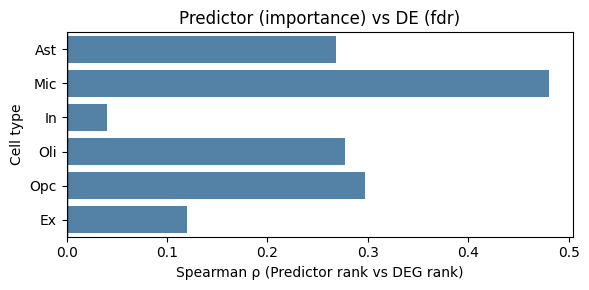

In [2]:
# ============================================================
# Predictor vs Random-Effects DEG Spearman Correlation Plots
# One standalone plotting script
# ============================================================

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ============================
# Paths
# ============================
deg_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
model_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/"

os.makedirs(out_dir, exist_ok=True)

cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]

results = []

# ============================
# Loop per cell type
# ============================
for ct in cell_types:
    print(f"\n=== {ct} ===")

    # ---------- Load DEG results ----------
    deg_path = os.path.join(deg_dir, f"poisson_DE_results_{ct}.csv")
    deg = pd.read_csv(deg_path)

    deg["gene"] = deg["gene"].str.strip()
    deg = deg.sort_values("p_adj", ascending=True)
    deg["deg_rank"] = np.arange(1, len(deg) + 1)

    # ---------- Load models & collect importances ----------
    all_split_data = {}
    all_features = set()

    for split in range(1, 6):
        model_path = os.path.join(
            model_dir, ct, f"split_{split}", "maximal_classifier.joblib"
        )
        model = joblib.load(model_path)

        feats = model.feature_names_in_
        imps = model.feature_importances_

        all_features.update(feats)
        all_split_data[split] = dict(zip(feats, imps))

    # ---------- Compute mean normalized importance ----------
    rows = []
    for gene in sorted(all_features):
        norm_imps = []

        for split in range(1, 6):
            imp = all_split_data[split].get(gene, 0.0)
            split_imps = np.array(list(all_split_data[split].values()))
            denom = split_imps[split_imps > 0].sum()

            norm_imps.append(imp / denom if imp > 0 and denom > 0 else 0.0)

        rows.append({
            "gene": gene.strip(),
            "mean_importance": np.mean(norm_imps)
        })

    imp_df = pd.DataFrame(rows)
    imp_df["pred_rank"] = imp_df["mean_importance"].rank(ascending=False)

    # ---------- Merge DEG + predictor ranks ----------
    merged = deg.merge(imp_df, on="gene", how="inner")

    # ---------- Spearman correlation ----------
    rho, p = spearmanr(merged["deg_rank"], merged["pred_rank"])
    print(f"Spearman rho = {rho:.3f}, p = {p:.2e}")

    results.append({
        "cell_type": ct,
        "spearman_rho": rho,
        "p_value": p,
        "n_genes": merged.shape[0]
    })

    # ---------- Save rank table ----------
    merged.to_csv(
        os.path.join(out_dir, f"{ct}_deg_predictor_rank_table.csv"),
        index=False
    )

    # # ============================
    # # Plot rank–rank correlation
    # # ============================
    # plt.figure(figsize=(4.5, 4))

    # sns.scatterplot(
    #     data=merged,
    #     x="deg_rank",
    #     y="pred_rank",
    #     s=12,
    #     alpha=0.4,
    #     edgecolor=None
    # )

    # plt.xlabel("Random-effects DEG rank")
    # plt.ylabel("Predictor importance rank")
    # plt.title(f"{ct} (ρ = {rho:.2f}, p = {p:.1e})")

    # # Top ranks = top-left
    # plt.gca().invert_xaxis()
    # plt.gca().invert_yaxis()

    # plt.tight_layout()
    # plt.savefig(
    #     os.path.join(out_dir, f"{ct}_deg_vs_predictor_spearman.png"),
    #     dpi=300
    # )
    # plt.show()

# ============================
# Save summary + FDR correction
# ============================
summary = pd.DataFrame(results)
summary["p_value_fdr"] = multipletests(
    summary["p_value"], method="fdr_bh"
)[1]

summary.to_csv(
    os.path.join(out_dir, "DEG_predictor_spearman_summary.csv"),
    index=False
)

print("\n=== FDR-adjusted Predictor–DEG correlations ===")
print(summary[["cell_type", "spearman_rho", "p_value", "p_value_fdr", "n_genes"]])
print("\nAll correlation plots generated.")


# ============================================================
# Summary plot: Predictor–DEG Spearman correlation by cell type
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Paths ===
summary_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/DEG_predictor_spearman_summary.csv"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/"

# === Load ===
df = pd.read_csv(summary_path)

# Order cell types (match figures elsewhere)
cell_order = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]
df["cell_type"] = pd.Categorical(df["cell_type"], categories=cell_order, ordered=True)
df = df.sort_values("cell_type")

# === Plot ===
plt.figure(figsize=(6, 3))

sns.barplot(
    data=df,
    x="spearman_rho",
    y="cell_type",
    color="steelblue"
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Spearman ρ (Predictor rank vs DEG rank)")
plt.ylabel("Cell type")
plt.title("Predictor (importance) vs DE (fdr)")

plt.tight_layout()
plt.savefig(
    os.path.join(out_dir, "spearman_summary_by_cell_type.png"),
    dpi=300
)
plt.show()

2026-01-16 18:37:53,795 [INFO] Parsing data files for GSEA.............................
2026-01-16 18:37:53,802 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2026-01-16 18:37:53,835 [INFO] 1115 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-16 18:37:53,845 [INFO] 0032 gene_sets used for further statistical testing.....
2026-01-16 18:37:53,846 [INFO] Start to run GSEA...Might take a while..................


Total background genes: 17926

Running DEG-based GSEA for: Ast


2026-01-16 18:37:53,967 [INFO] Congratulations. GSEApy runs successfully................



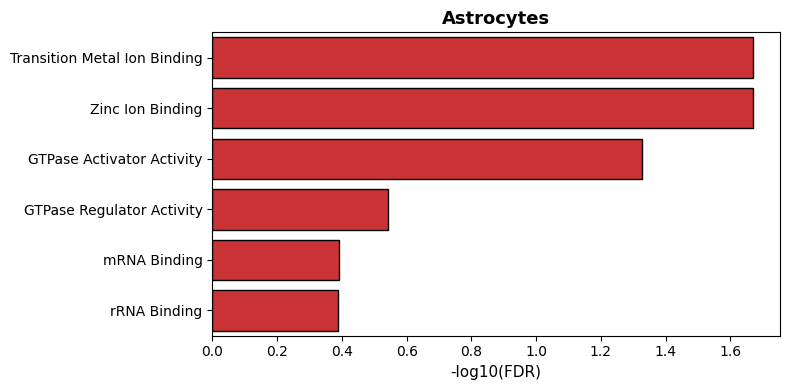

2026-01-16 18:37:55,790 [INFO] Parsing data files for GSEA.............................
2026-01-16 18:37:55,796 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2026-01-16 18:37:55,843 [INFO] 0796 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-16 18:37:55,854 [INFO] 0351 gene_sets used for further statistical testing.....
2026-01-16 18:37:55,856 [INFO] Start to run GSEA...Might take a while..................


  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/PathwayAnalysis_GSEA_DEGs/Ast_DEG_gsea_plot_filtered.png

Running DEG-based GSEA for: Ex


2026-01-16 18:38:02,694 [INFO] Congratulations. GSEApy runs successfully................



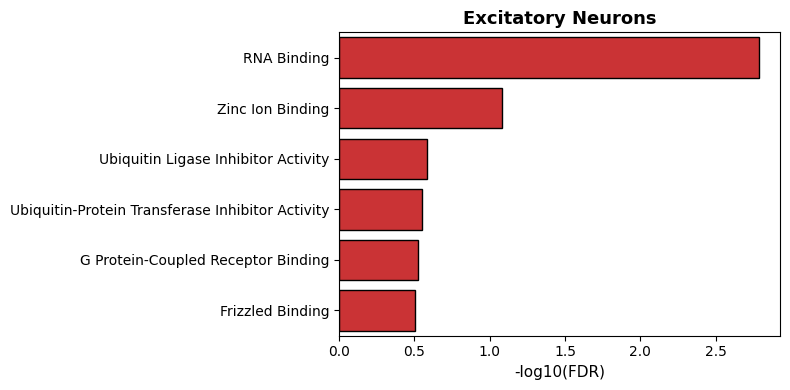

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
2026-01-16 18:38:03,878 [WARNING] Input gene rankings contains inf values!
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/gseapy/gsea.py:507: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  rankser.replace(-np.inf, method="ffill", inplace=True)
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/gseapy/gsea.py:508: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  rankser.replace(np.inf, method="bfill", inplace=True)
2026-01-16 18:38:03,883 [WARNING] Duplicated values found in preranked stats: 0.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-16 18:38:03,884 [INFO] Parsing data files for GSEA......

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/PathwayAnalysis_GSEA_DEGs/Ex_DEG_gsea_plot_filtered.png

Running DEG-based GSEA for: In


2026-01-16 18:38:04,112 [INFO] Congratulations. GSEApy runs successfully................



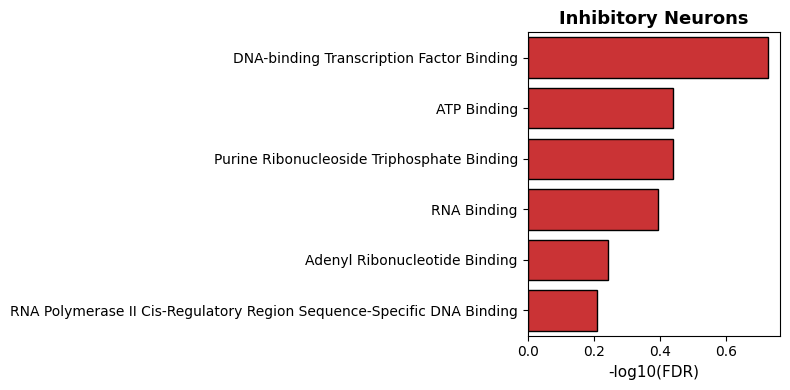

2026-01-16 18:38:05,436 [INFO] Parsing data files for GSEA.............................
2026-01-16 18:38:05,439 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2026-01-16 18:38:05,457 [INFO] 1134 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-16 18:38:05,472 [INFO] 0013 gene_sets used for further statistical testing.....
2026-01-16 18:38:05,473 [INFO] Start to run GSEA...Might take a while..................
2026-01-16 18:38:05,499 [INFO] Congratulations. GSEApy runs successfully................



  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/PathwayAnalysis_GSEA_DEGs/In_DEG_gsea_plot_filtered.png

Running DEG-based GSEA for: Mic


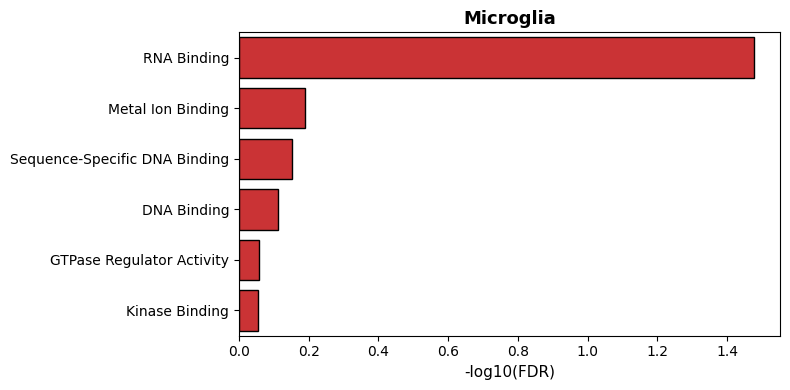

2026-01-16 18:38:06,754 [INFO] Parsing data files for GSEA.............................
2026-01-16 18:38:06,758 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2026-01-16 18:38:06,790 [INFO] 1045 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-16 18:38:06,801 [INFO] 0102 gene_sets used for further statistical testing.....
2026-01-16 18:38:06,805 [INFO] Start to run GSEA...Might take a while..................


  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/PathwayAnalysis_GSEA_DEGs/Mic_DEG_gsea_plot_filtered.png

Running DEG-based GSEA for: Oli


2026-01-16 18:38:07,515 [INFO] Congratulations. GSEApy runs successfully................



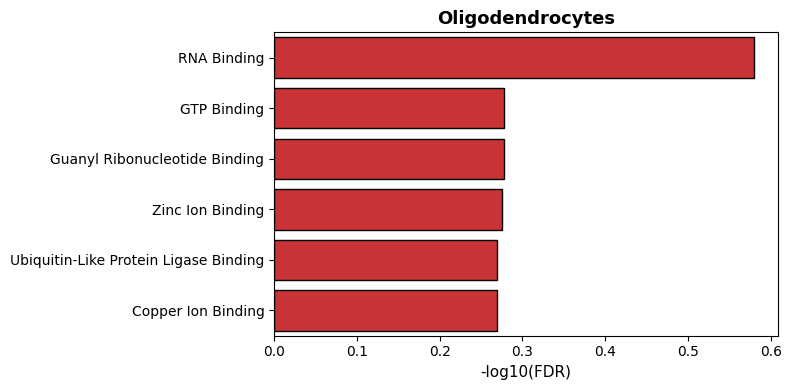

2026-01-16 18:38:09,049 [INFO] Parsing data files for GSEA.............................
2026-01-16 18:38:09,050 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2026-01-16 18:38:09,075 [INFO] 1138 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-16 18:38:09,077 [INFO] 0009 gene_sets used for further statistical testing.....
2026-01-16 18:38:09,079 [INFO] Start to run GSEA...Might take a while..................
2026-01-16 18:38:09,101 [INFO] Congratulations. GSEApy runs successfully................



  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/PathwayAnalysis_GSEA_DEGs/Oli_DEG_gsea_plot_filtered.png

Running DEG-based GSEA for: Opc


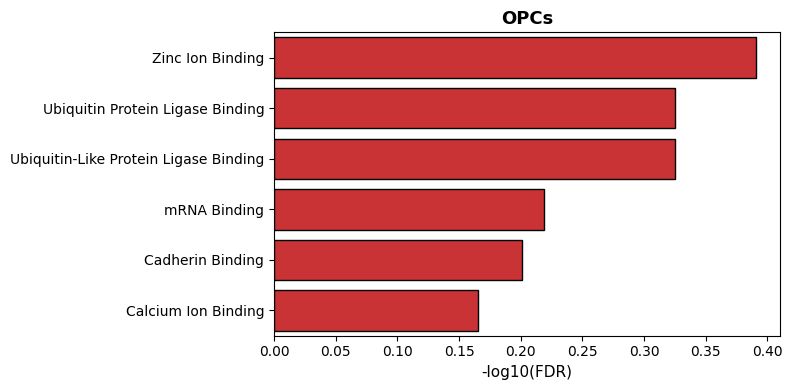

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/PathwayAnalysis_GSEA_DEGs/Opc_DEG_gsea_plot_filtered.png


In [7]:


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gseapy import prerank

# === Setup (UNCHANGED) ===
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure6/"
pathway_dir = os.path.join(output_dir, "PathwayAnalysis_GSEA_DEGs")
os.makedirs(pathway_dir, exist_ok=True)

ct_labels = {
    'Ast': 'Astrocytes',
    'Ex': 'Excitatory Neurons',
    'In': 'Inhibitory Neurons',
    'Mic': 'Microglia',
    'Oli': 'Oligodendrocytes',
    'Opc': 'OPCs'
}

# === DEG paths ===
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In":  "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex":  "poisson_DE_results_Ex.csv"
}

# === Background genes (UNCHANGED) ===
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())
print(f"Total background genes: {len(background_genes)}")

# === Stylized plot (UNCHANGED) ===
def plot_pathways_gsea(df, title, save_path, top_n=6, color="#1f78b4"):
    df = df.copy()
    df = df[df["fdr"].notna()]
    df = df[pd.to_numeric(df["fdr"], errors="coerce").notna()]
    df = df.sort_values("fdr", ascending=True).head(top_n)

    if df.empty:
        print(f"  No enriched terms for {title}")
        return

    df["name"] = (
        df["Term"]
        .str.replace(r"^GO_Molecular_Function_2023__", "", regex=True)
        .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
        .str.replace("_", " ")
        .str.strip()
    )

    df["-log10(FDR)"] = -np.log10(df["fdr"].astype(float))

    plt.figure(figsize=(8, 4))
    sns.barplot(
        x="-log10(FDR)",
        y="name",
        data=df,
        color=color,
        edgecolor="black"
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("-log10(FDR)", fontsize=11)
    plt.ylabel("")
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600)
    plt.show()
    print(f"  Saved: {save_path}")

# === DEG-BASED GSEA LOOP (ONLY CHANGE IS HERE) ===
for cell_type in ct_labels.keys():
    print(f"\nRunning DEG-based GSEA for: {cell_type}")

    # Load DEG table
    df = pd.read_csv(os.path.join(de_base_dir, de_files[cell_type]))

    # Use same DEG cutoff as your figures
    df = df[(df["p_adj"] < 0.05) & (df["gene"].notna())]

    if df.shape[0] < 10:
        print(f"  Too few DEGs for {cell_type}. Skipping.")
        continue

    # === RANKING SCORE (key swap) ===
    # Signed effect size × confidence
    # (very standard for DE-GSEA)
    df["score"] = df["log2FC"] * (-np.log10(df["p_adj"]))

    ranked_genes = (
        df[["gene", "score"]]
        .drop_duplicates()
        .set_index("gene")["score"]
        .to_dict()
    )

    # === Write .rnk (UNCHANGED FORMAT) ===
    rnk_df = pd.DataFrame(ranked_genes.items(), columns=["gene_name", "score"])
    rnk_df["gene_name"] = rnk_df["gene_name"].str.upper()
    rnk_df = rnk_df.sort_values("score", ascending=False)

    rnk_path = os.path.join(pathway_dir, f"{cell_type}.rnk")
    rnk_df.to_csv(
        rnk_path,
        sep="\t",
        index=False,
        header=False,
        float_format="%.16g"
    )

    # === Run GSEA (UNCHANGED) ===
    pre_res = prerank(
        rnk=rnk_path,
        gene_sets=[
            "GO_Molecular_Function_2023"
        ],
        background=list(background_genes),
        outdir=None,
        seed=0,
        verbose=True,
        min_size=5,
        max_size=1000
    )

    # === Save and plot (UNCHANGED) ===
    gsea_df_full = pre_res.res2d.reset_index().rename(columns={"FDR q-val": "fdr"})
    gsea_df_full.to_csv(
        os.path.join(pathway_dir, f"{cell_type}_DEG_gsea_results_unfiltered.csv"),
        index=False
    )

    plot_pathways_gsea(
        gsea_df_full,
        title=ct_labels[cell_type],
        save_path=os.path.join(pathway_dir, f"{cell_type}_DEG_gsea_plot_filtered.png"),
        top_n=6,
        color="#e31a1c"
    )

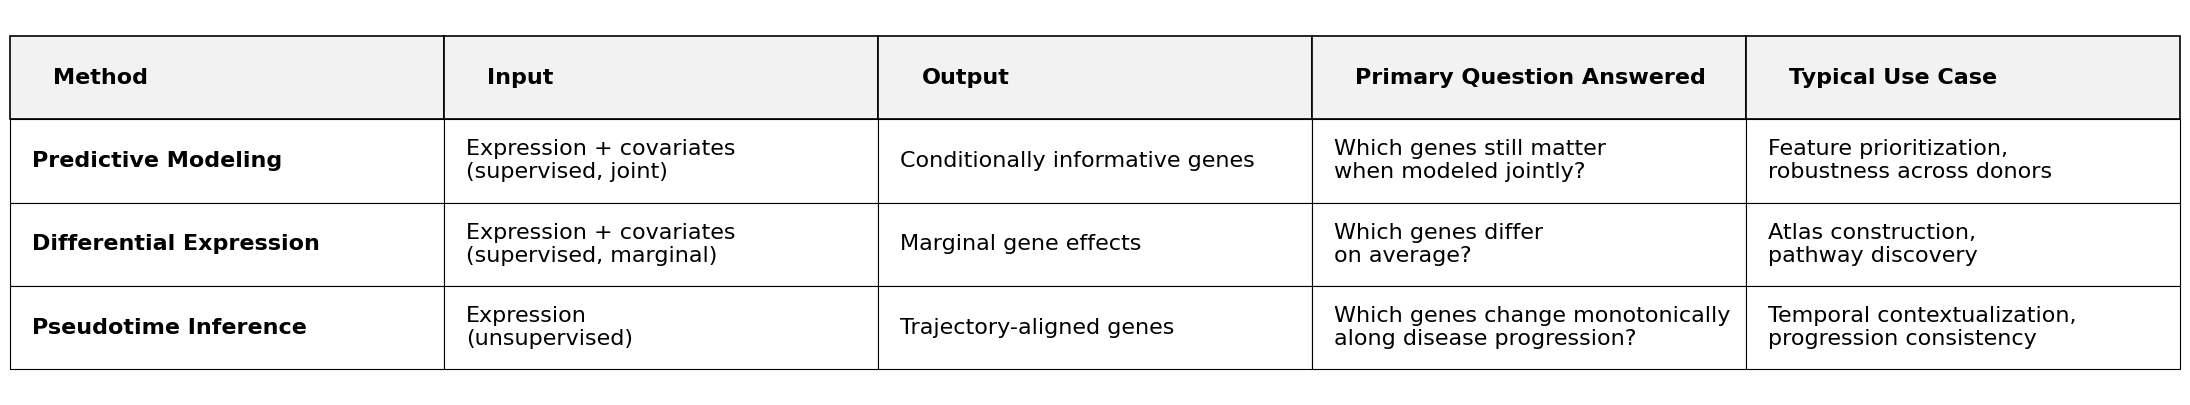

In [1]:
import matplotlib.pyplot as plt

# -----------------------------
# Table content
# -----------------------------
columns = [
    "Method",
    "Input",
    "Output",
    "Primary Question Answered",
    "Typical Use Case"
]

# rows = [
#     [
#         "Machine Learning",
#         "Multivariate expression\n+ covariates",
#         "Conditionally informative genes",
#         "Which genes still matter\nwhen modeled jointly?",
#         "Feature prioritization,\nrobustness across donors"
#     ],
#     [
#         "Differential Expression",
#         "Case–control labels",
#         "Marginal gene effects",
#         "Which genes differ\non average?",
#         "Atlas construction,\npathway discovery"
#     ],
#     [
#         "Pseudotime Inference",
#         "Unsupervised transcriptional\nstructure",
#         "Trajectory-aligned genes",
#         "Which genes change monotonically\nalong disease progression?",
#         "Temporal contextualization,\nprogression consistency"
#     ]
# ]

rows = [
    [
        "Predictive Modeling",
        "Expression + covariates\n(supervised, joint)",
        "Conditionally informative genes",
        "Which genes still matter\nwhen modeled jointly?",
        "Feature prioritization,\nrobustness across donors"
    ],
    [
        "Differential Expression",
        "Expression + covariates\n(supervised, marginal)",
        "Marginal gene effects",
        "Which genes differ\non average?",
        "Atlas construction,\npathway discovery"
    ],
    [
        "Pseudotime Inference",
        "Expression\n(unsupervised)",
        "Trajectory-aligned genes",
        "Which genes change monotonically\nalong disease progression?",
        "Temporal contextualization,\nprogression consistency"
    ]
]

# -----------------------------
# Create figure (TALLER)
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

# Build table
table = ax.table(
    cellText=rows,
    colLabels=columns,
    loc="center",
    cellLoc="left",
    colLoc="left"
)

# -----------------------------
# Formatting
# -----------------------------
table.auto_set_font_size(False)
# table.set_fontsize(14)

# IMPORTANT: increase vertical scale
table.scale(2, 5)
table.set_fontsize(13)
# Force font size on every cell (THIS is the fix)
for (row, col), cell in table.get_celld().items():
    cell.get_text().set_fontsize(16)

# Header formatting
for col in range(len(columns)):
    cell = table[0, col]
    cell.set_text_props(weight="bold")
    cell.set_facecolor("#F2F2F2")
    cell.set_edgecolor("black")
    cell.set_linewidth(1.2)
    cell.PAD = 0.1

# Body formatting
for row in range(1, len(rows) + 1):
    for col in range(len(columns)):
        cell = table[row, col]
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
        cell.PAD = 0.05

        # Emphasize method names
        if col == 0:
            cell.set_text_props(weight="bold")

# -----------------------------
# Save figure
# -----------------------------
plt.savefig(
    "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Extended_Data_Figure_1_Method_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Extended_Data_Figure_1_Method_Comparison.pdf",
    bbox_inches="tight"
)

plt.show()